In [233]:
# Imports
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import WCSAxes
from astropy.coordinates import SkyCoord, FK5
from spectral_cube import SpectralCube
from velocity_tools import extract_streamline, gradient_descent, stream_lines_grad
from velocity_tools import stream_lines # won't use this directly, but needed to compare with stream_lines_grad
import os
import numpy as np
import jax
import jax.numpy as jnp
from jax import value_and_grad
import pandas as pd


import warnings
warnings.filterwarnings('ignore', message='.*PV2_1.*')
warnings.filterwarnings('ignore', message='.*PV2_2.*')
warnings.filterwarnings('ignore', message='.*TIMESYS.*')

# Settings
hltau_c= SkyCoord("4h31m38.43s", "+18d13m57.19s", frame='fk5')
hltau_ref = hltau_c.skyoffset_frame()
distance = 147 #parsecs
cubefile = 'test_data/HLTAU_HCOp32.fits'
file_TdV = 'test_data/HLTAU_HCOp32_TdV.fits'


### TODO: Extract streamer cube from original cube

Do this here

### Prepare the 1D streamer emission from the cube

In [234]:
# get the spectralcube object from the data using spectral-cube
hdu = fits.open(cubefile)[0]
cube = SpectralCube.read(hdu).with_spectral_unit(u.km/u.s, rest_value=hdu.header['RESTFRQ']*u.Hz)

# if the mom0 map isn't made yet, make it
if not os.path.exists(file_TdV):
    cube_mom0 = cube.moment0()
    hdu_mom0 = cube_mom0.hdu
    hdu_mom0.writeto(file_TdV)
print("Loaded cube with shape:", cube.shape)

# TODO: this streamer extraction should be replaced with clustering-based streamer extraction

# extract the subcube with the streamer (we got this from the tipsy tutorial, no need to plot)
## Limits for extracting subcube with streamer
vmin = 7    # Min. vel. of streamer
vmax = 10
xmin = -3   # Min R.A. offset (arcsec) to consider for streamer
xmax = -1
ymin = -3   # Min. Decl. offset (arcsec) to consider for streamer
ymax = 0.5
rms_thresh = 4  # sigma threshold for streamer

# extract the streamer subcube
info_header = cube.header  # header of the cube, contains required information
x_conv_fac = 1/60/60/info_header['CDELT1']
xmin_p = int((xmin*x_conv_fac)+info_header['CRPIX1'])
xmax_p = int((xmax*x_conv_fac)+info_header['CRPIX1'])
y_conv_fac = 1/60/60/info_header['CDELT2']
ymin_p = int((ymin*y_conv_fac)+info_header['CRPIX2'])
ymax_p = int((ymax*y_conv_fac)+info_header['CRPIX2'])
vunit = cube.spectral_axis.unit
## Note: a check can be added to see if requested limits are within the limits of the cube itself

streamer_cubev = cube.spectral_slab(vmin*vunit,vmax*vunit)    # Selecting velocities
streamer_cubevc = streamer_cubev[:,min(ymin_p,ymax_p):max(ymin_p,ymax_p)   
                    ,min(xmin_p,xmax_p):max(xmin_p,xmax_p)]   # Selecting pixels
#     print(min(ymin_p,ymax_p),max(ymin_p,ymax_p),min(xmin_p,xmax_p),max(xmin_p,xmax_p)) 
streamer_cube = streamer_cubevc.with_mask(streamer_cubevc > rms_thresh*streamer_cubevc.mad_std())  # Removing low flux values 


Loaded cube with shape: (500, 401, 401)


In [235]:
n_points = 10 # the number of points we want to reduce the data to


# Extract 1D streamline from the data cube
pc_coords, pc_means, pc_stds = extract_streamline.reduce_to_1D(streamer_cube, n_elements=n_points)

# Prepare data for gradient descent
ra_data = pc_means[0] # offsets in arcsec
dec_data = pc_means[1] # offsets in arcsec
v_data = pc_means[2]   # velocities in km/s (rel to vlsr)

ra_sigma = pc_stds[0]
dec_sigma = pc_stds[1]
v_sigma = pc_stds[2]


data = (ra_data, dec_data, v_data)
uncertainties = (ra_sigma, dec_sigma, v_sigma)

Starting reduction
Created coordinate arrays
Got point cloud with 14974 points
Partition boundaries for projected distance metric: [1.031 1.122 1.176 1.234 1.3   1.383 1.48  1.602 1.732 1.898 3.251]


Text(0.5, 1.0, 'Extracted 1D Streamer emission')

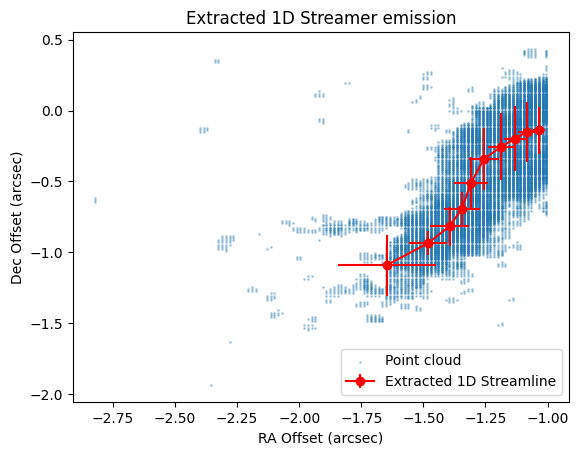

In [236]:
# plot it
import matplotlib.pyplot as plt
# plot the observed data points as a scatter
plt.scatter(pc_coords[0], pc_coords[1], s=1, alpha=0.3, label='Point cloud')
# plot the extracted 1D streamline with error bars
plt.errorbar(ra_data, dec_data, xerr=ra_sigma, yerr=dec_sigma, fmt='o-', label='Extracted 1D Streamline', color='red')
plt.xlabel('RA Offset (arcsec)')
plt.ylabel('Dec Offset (arcsec)')
plt.legend()
plt.title('Extracted 1D Streamer emission')

### Initial guess at parameters, and plot

The plot is so you can refine your initial parameters a bit. The comparison between stream_lines and stream_lines_grad is just a sanity check and will be removed

Running stream_lines...
r = [500. 460. 420. 380. 340. 300. 260. 220. 180. 140. 100.  60.] AU
rc=10.72530486416399 AU
ecc=0.9917936340559448
mu=0.019861675674377757
theta0=40.0 deg
orb_ang=0.0 rad
40.0 AU
tolerance  1.4361395587200003e-05
theta = [0.69891303 0.69983796 0.7009428  0.70226658 0.70390525 0.70598069
 0.70867778 0.71234816 0.71762234 0.72584942 0.74046217 0.77368319] rad
phi = [3.89603953 3.92291251 3.94645102 3.96909107 3.99248495 4.01768212
 4.04577026 4.07858751 4.11879761 4.17140672 4.24722301 4.37721983] rad
---------------------------------------------
Running stream_lines_grad...
Plotting results...


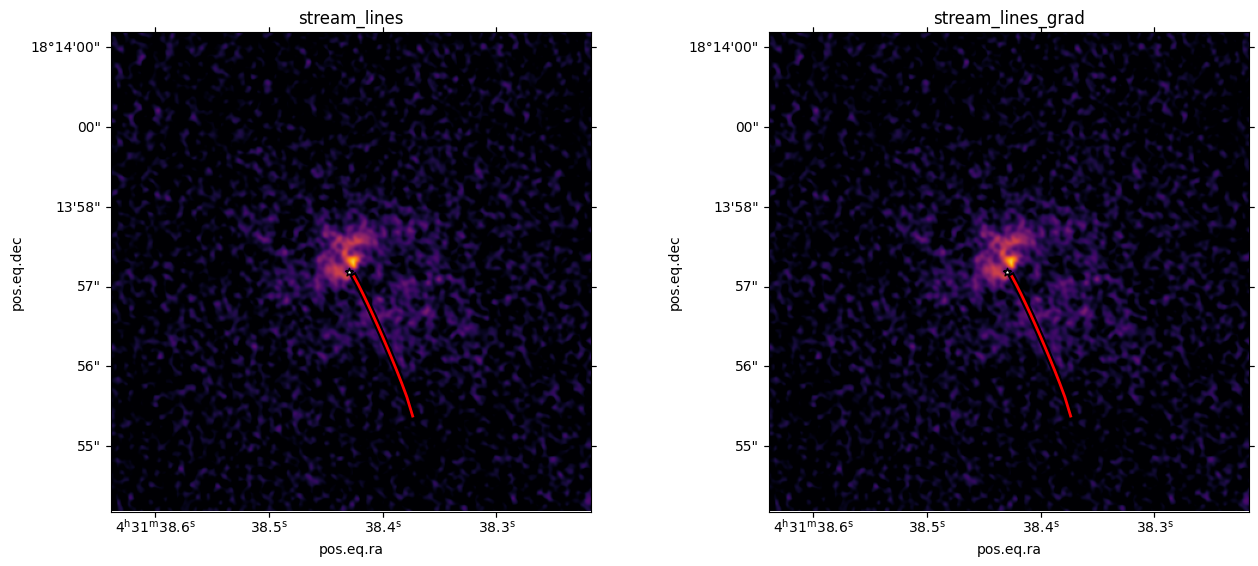

Saved streamline coordinates to streamline_comparison_data.csv


In [237]:
# Initial guesses at params
r0 = 540*u.au
theta0 = 40.*u.deg
phi0 = 220.*u.deg
omega0 = 4e-12/u.s
v_r0 = 0*u.km/u.s
# params we set
Mstar = 3.2*u.Msun
inc = -47*u.deg
PA_ang = 138*u.deg
v_lsr = 7.0*u.km/u.s


# Run the forward model with initial params - using stream_lines
# x = RA offset (au), y = velocity (km/s), z = Dec offset (au)
print("Running stream_lines...")
(x1, y1, z1), (vx1, vy1, vz1) = stream_lines.xyz_stream(
                mass=Mstar, r0=r0, theta0=theta0, phi0=phi0,
                omega=omega0, v_r0=v_r0, inc=inc, pa=PA_ang,
                rmin=0.5e2*u.au, deltar=40*u.au) #<- decrease deltar for more accurate streamer calculation
dra_stream1 = -x1.value / distance * u.arcsec 
ddec_stream1 = z1.value / distance * u.arcsec
fil1 = SkyCoord(dra_stream1, ddec_stream1, frame=hltau_ref).transform_to(FK5)

print("---------------------------------------------")

# Run the forward model with initial params - using stream_lines_grad
# convert angles to radians, and strip units from all quantities
r0 = r0.to(u.au).value
theta0 = theta0.to(u.rad).value
phi0 = phi0.to(u.rad).value
omega0 = omega0.to(1/u.s).value
v_r0 = v_r0.to(u.km/u.s).value
inc = inc.to(u.rad).value
PA_ang = PA_ang.to(u.rad).value
Mstar = Mstar.to(u.Msun).value
v_lsr = v_lsr.to(u.km/u.s).value
# x = RA offset (au), y = velocity (km/s), z = Dec offset (au)
print("Running stream_lines_grad...")
(x2, y2, z2), (vx2, vy2, vz2) = stream_lines_grad.xyz_stream(
                mass=Mstar, r0=r0, theta0=theta0, phi0=phi0,
                omega=omega0, v_r0=v_r0, inc=inc, pa=PA_ang,
                rmin=0.5e2, deltar=40) #<- decrease deltar for more accurate streamer calculation
dra_stream2 = -np.array(x2, dtype=np.float64) / distance * u.arcsec # note the _value to get raw number for stream_lines_grad
ddec_stream2 = np.array(z2, dtype=np.float64) / distance * u.arcsec
fil2 = SkyCoord(dra_stream2, ddec_stream2, frame=hltau_ref).transform_to(FK5)

print("Plotting results...")
# Load the moment 0 data
hdu = fits.open(file_TdV)[0]
wcs_TdV = WCS(hdu.header)

# Create figure with two subplots side by side
plt.close('all')
fig = plt.figure(figsize=(14, 6))

# Left subplot - stream_lines
ax1 = WCSAxes(fig, [0.05, 0.1, 0.4, 0.8], wcs=wcs_TdV.celestial)
fig.add_axes(ax1)
im1 = ax1.imshow(hdu.data, cmap='inferno', vmin=0, vmax=160.e-3)
ax1.scatter(hltau_c.ra, hltau_c.dec, marker='*', transform=ax1.get_transform('world'),
    facecolor='white', edgecolor='black')
ax1.plot(fil1.ra, fil1.dec, color='black', transform=ax1.get_transform('world'), linewidth=5)
ax1.plot(fil1.ra, fil1.dec, color='red', transform=ax1.get_transform('world'), linewidth=2)
ax1.set_title('stream_lines')

# Right subplot - stream_lines_grad
ax2 = WCSAxes(fig, [0.52, 0.1, 0.4, 0.8], wcs=wcs_TdV.celestial)
fig.add_axes(ax2)
im2 = ax2.imshow(hdu.data, cmap='inferno', vmin=0, vmax=160.e-3)
ax2.scatter(hltau_c.ra, hltau_c.dec, marker='*', transform=ax2.get_transform('world'),
    facecolor='white', edgecolor='black')
ax2.plot(fil2.ra, fil2.dec, color='black', transform=ax2.get_transform('world'), linewidth=5)
ax2.plot(fil2.ra, fil2.dec, color='red', transform=ax2.get_transform('world'), linewidth=2)
ax2.set_title('stream_lines_grad')


plt.show()


# Save streamline coordinates to CSV
streamline_data = pd.DataFrame({
    'x1': np.asarray(x1),
    'y1': np.asarray(y1),
    'z1': np.asarray(z1),
    'vx1': np.asarray(vx1),
    'vy1': np.asarray(vy1),
    'vz1': np.asarray(vz1),
    'ra1': fil1.ra.deg,
    'dec1': fil1.dec.deg,
    'dra1': dra_stream1.value,
    'ddec1': ddec_stream1.value,
    'x2': np.asarray(x2),
    'y2': np.asarray(y2),
    'z2': np.asarray(z2),
    'vx2': np.asarray(vx2),
    'vy2': np.asarray(vy2),
    'vz2': np.asarray(vz2),
    'ra2': fil2.ra.deg,
    'dec2': fil2.dec.deg,
    'dra2': dra_stream2.value,
    'ddec2': ddec_stream2.value,
})
streamline_data.to_csv('streamline_comparison_data.csv', index=False)
print(f"Saved streamline coordinates to streamline_comparison_data.csv")


### Forward model and calculating loss

First set your input params in the format required

In [238]:
# Parameters to optimize
initial_opt_params = {
    'r0': 540.0,  # au
    'theta0': 40.0,  # degrees
    'phi0': 220.0,  # degrees
    'omega': 4e-12,  # 1/s
    'v_r0': 0.0,  # km/s
}

# Fixed parameters (not optimized)
fixed_params = {
    'mass': 3.2,  # Msun
    'inc': -47.0,  # degrees
    'pa': 138.0,  # degrees
    'rmin': 50.0,  # au
    'deltar': 40.0,  # au
    'v_lsr': 7  # km/s (systemic velocity)
}

# Convert angles from degrees to radians
initial_opt_params['theta0'] = np.radians(initial_opt_params['theta0'])
initial_opt_params['phi0'] = np.radians(initial_opt_params['phi0'])
fixed_params['inc'] = np.radians(fixed_params['inc'])
fixed_params['pa'] = np.radians(fixed_params['pa'])

Doing chi2 loss more manually, just so we can check the model point choosing is working properly (delete this later)

Chi-squared RA: 1086.56, Dec: 252.17, Velocity: 37155.29, Total: 38494.02


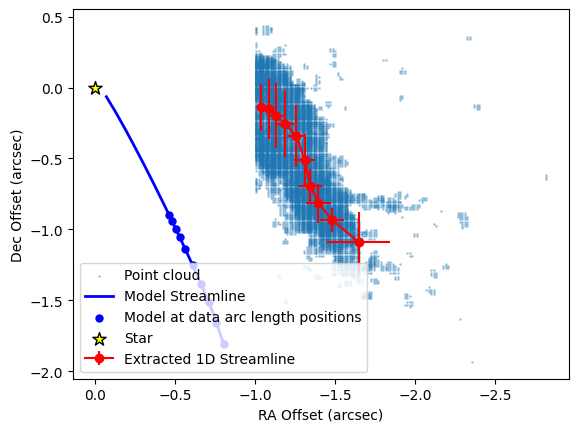

In [239]:
# forward model
ra_model, dec_model, v_model = gradient_descent.forward_model(initial_opt_params, fixed_params, distance)
# remove NaN values
not_nan = ~jnp.isnan(ra_model) & ~jnp.isnan(dec_model) & ~jnp.isnan(v_model)
ra_model = ra_model[not_nan]
dec_model = dec_model[not_nan]
v_model = v_model[not_nan]

# Match model to data using arc-length parameterisation
ra_model_interp, dec_model_interp, v_model_interp, valid = gradient_descent.match_model_to_data_curve(
    ra_model, dec_model, v_model, ra_data, dec_data)

# mask for valid (only for arrays that haven't already been masked in matching)
v_data = v_data[valid]
ra_sigma = ra_sigma[valid]
dec_sigma = dec_sigma[valid]
v_sigma = v_sigma[valid]

# compute chi2
chi2_ra = jnp.sum(((ra_data - ra_model_interp) / ra_sigma)**2)
chi2_dec = jnp.sum(((dec_data - dec_model_interp) / dec_sigma)**2)
chi2_v = jnp.sum(((v_data - v_model_interp) / v_sigma)**2)
# Total chi-squared
chi2_total = chi2_ra + chi2_dec + chi2_v
print(f"Chi-squared RA: {chi2_ra:.2f}, Dec: {chi2_dec:.2f}, Velocity: {chi2_v:.2f}, Total: {chi2_total:.2f}")


# plot it
import matplotlib.pyplot as plt
# plot the observed data points as a scatter
plt.scatter(pc_coords[0], pc_coords[1], s=1, alpha=0.3, label='Point cloud')
# plot the extracted 1D data streamline with error bars
plt.errorbar(ra_data, dec_data, xerr=ra_sigma, yerr=dec_sigma, fmt='o-', label='Extracted 1D Streamline', color='red')
# plot the model streamline
plt.plot(ra_model, dec_model, 'b-', linewidth=2, label='Model Streamline')
# plot the model streamline at data arc length positions
plt.scatter(ra_model_interp, dec_model_interp, s=25, label='Model at data arc length positions', color='blue', zorder=5)
# plot the star
plt.scatter(0, 0, marker='*', s=100, color='yellow', edgecolor='black', label='Star', zorder=10)
# invert x axis to match RA offset direction
plt.gca().invert_xaxis()
plt.xlabel('RA Offset (arcsec)')
plt.ylabel('Dec Offset (arcsec)')
plt.legend()


In [240]:
# All the above could be done just by calling chi2_loss
initial_loss = gradient_descent.chi2_loss(initial_opt_params, fixed_params, data, uncertainties, distance)
print(f"Initial chi-squared loss: {initial_loss:.2f}")

Initial chi-squared loss: 38494.02


### Testing one gradient descent step (the first step)

In [241]:
opt_params = initial_opt_params.copy()

# Initialize Adam moments (only for optimizable parameters)
m = {key: 0.0 for key in opt_params.keys()}
v = {key: 0.0 for key in opt_params.keys()}
# let's set learning rate and Adam parameters (I don't really know what these are)
learning_rate = 1e-2
beta1 = 0.9
beta2 = 0.999

# Create gradient function (only w.r.t. opt_params)
loss_and_grad_fn = value_and_grad(gradient_descent.chi2_loss, argnums=0)

# track loss history
loss_history = []
best_loss = float('inf')
best_opt_params = opt_params.copy()
patience_counter = 0

# let's just do one epoch to test
# Get loss and gradients
loss_value, grads = loss_and_grad_fn(opt_params, fixed_params, data, uncertainties, distance)
print(f"Initial loss: {loss_value:.2f}")
print(f"grads: {grads}")
# perform one Adam update to params
opt_params, m, v = gradient_descent.adam_step(
    opt_params, grads, m, v, t=1, learning_rate=learning_rate, beta1=beta1, beta2=beta2
)

# track loss
loss_history.append(loss_value)

# print new params
print("Updated parameters after one Adam step:")
for key in opt_params.keys():
    print(f"  {key}: {opt_params[key]:.6f}")

Initial loss: 38494.02
grads: {'omega': Array(-6.539908e+13, dtype=float32), 'phi0': Array(8650.349, dtype=float32), 'r0': Array(-19.404062, dtype=float32), 'theta0': Array(-18734.7, dtype=float32), 'v_r0': Array(398.19504, dtype=float32, weak_type=True)}
Updated parameters after one Adam step:
  r0: 540.010010
  theta0: 0.708132
  phi0: 3.829724
  omega: 0.010000
  v_r0: -0.010000


### Testing full fit_streamline

### Using per-parameter learning rates

Since parameters are on very different scales (e.g., omega~1e-12, r0~600), we need different learning rates for each parameter to avoid instability.

Logging optimization progress to: optimisation_log.csv
Starting optimization with 30 epochs...
Optimizing parameters: ['r0', 'theta0', 'phi0', 'omega', 'v_r0']
Fixed parameters: ['mass', 'inc', 'pa', 'rmin', 'deltar', 'v_lsr']
Initial optimizable values: {'r0': 540.0, 'theta0': np.float64(0.6981317007977318), 'phi0': np.float64(3.839724354387525), 'omega': 4e-12, 'v_r0': 0.0}

 Starting Epoch 5 -------------------------
Epoch 5/30, Loss: 33248.437500, Best Loss: 33248.437500
  Current optimizable params: {'r0': Array(999.74084, dtype=float32), 'theta0': Array(1.1222836, dtype=float32), 'phi0': Array(3.577066, dtype=float32), 'omega': Array(4.0446453e-12, dtype=float32), 'v_r0': Array(0.01546824, dtype=float32, weak_type=True)}

 Starting Epoch 10 -------------------------
Epoch 10/30, Loss: 33143.265625, Best Loss: 32175.451172
  Current optimizable params: {'r0': Array(1252.6438, dtype=float32), 'theta0': Array(1.0037091, dtype=float32), 'phi0': Array(3.7951486, dtype=float32), 'omega

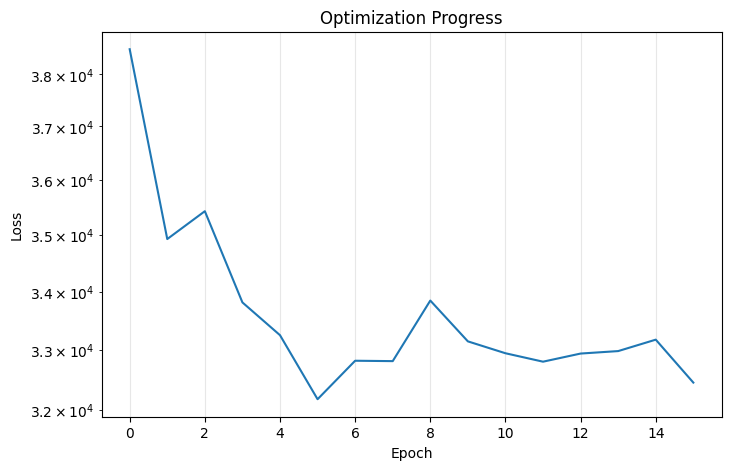

In [242]:
opt_params = initial_opt_params.copy()

# Define per-parameter learning rates based on parameter scales
# This is optional in the code but highly recommended due to differing parameter scales
learning_rates = {
    'r0': 100,          # order 10^3 au - use larger learning rate
    'theta0': 0.2,     # 0-pi radians - moderate learning rate
    'phi0': 0.4,       # 0-2pi radians - moderate learning rate
    'omega': 1e-14,      # order 10^-13 - use much smaller learning rate
    'v_r0': 0.2        # ~0-5 km/s - moderate learning rate
}

# Define physically reasonable bounds (this is optional in the code)
param_bounds = {
    'r0': (100.0, 20000.0),         # radius between 100-20000 au
    'theta0': (0.0, np.pi),         # polar angle 0-pi
    'phi0': (0.0, 2*np.pi),         # azimuthal angle 0-2pi
    'omega': (1e-16, 1e-9),         # angular velocity reasonable range.
    'v_r0': (-5.0, 5.0)             # radial velocity -5 to 5 km/s
}
#TODO: might need to scale omega for better precision as the numbers are really small

log_file = 'optimisation_log.csv'

best_opt_params, loss_history = gradient_descent.fit_streamline(
    opt_params,
    fixed_params,
    data, 
    uncertainties,
    distance,
    learning_rate=0.001,
    learning_rate_dict=learning_rates,
    param_bounds=param_bounds,
    n_epochs=30,
    info_every=5,
    early_stopping_patience=10,
    log_file=log_file

)

print("Done!")
print("---------------------------------------------")
print("Best-fit parameters:")
for key in best_opt_params.keys():
    print(f"  {key}: {best_opt_params[key]:.10f}")
    
# Plot loss history
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Optimization Progress')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()


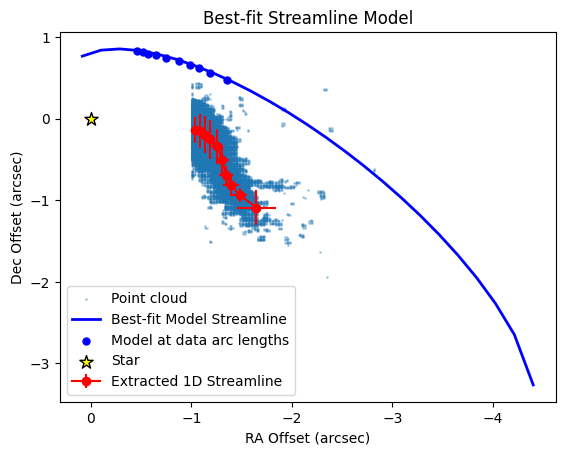

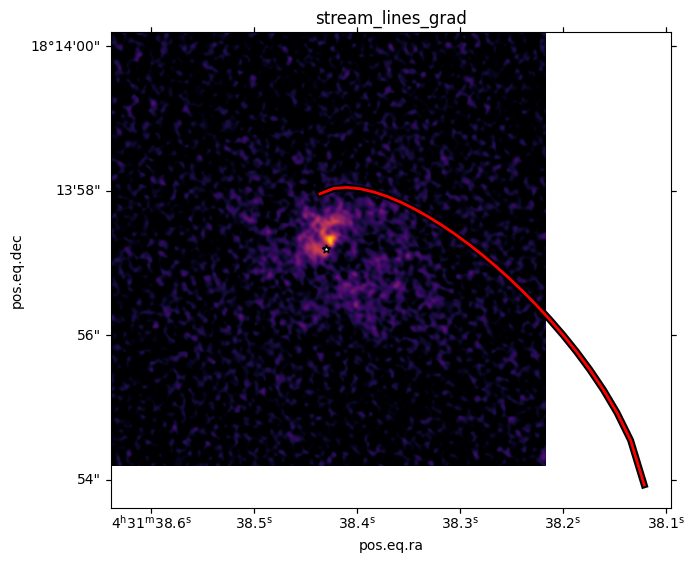

In [243]:
# Final model with best-fit parameters
ra_best, dec_best, v_best = gradient_descent.forward_model(best_opt_params, fixed_params, distance)
# remove NaN values (due to rmin) from model
not_nan = ~jnp.isnan(ra_best) & ~jnp.isnan(dec_best) & ~jnp.isnan(v_best)
ra_best = ra_best[not_nan]
dec_best = dec_best[not_nan]
v_best = v_best[not_nan]
# plot it on top of the data
plt.scatter(pc_coords[0], pc_coords[1], s=1, alpha=0.3, label='Point cloud')
# plot the extracted 1D data streamline with error bars
plt.errorbar(ra_data, dec_data, xerr=ra_sigma, yerr=dec_sigma, fmt='o-', label='Extracted 1D Streamline', color='red')
# plot the best-fit model streamline
plt.plot(ra_best, dec_best, color='blue', linewidth=2, label='Best-fit Model Streamline')
# get the model positions at data arc length points
ra_best_interp, dec_best_interp, v_best_interp, valid = gradient_descent.match_model_to_data_curve(
    ra_best, dec_best, v_best, ra_data, dec_data)
# plot the model posiitons at data arc length points
plt.scatter(ra_best_interp, dec_best_interp, s=25, label='Model at data arc lengths', color='blue', zorder=5)
# plot the star
plt.scatter(0, 0, marker='*', s=100, color='yellow', edgecolor='black', label='Star', zorder=10)
plt.xlabel('RA Offset (arcsec)')
plt.ylabel('Dec Offset (arcsec)')
# invert x axis to match RA offset direction
plt.gca().invert_xaxis()
plt.legend()
plt.title('Best-fit Streamline Model')
plt.show()


# plot the best model on the moment 0 map
# importatant to convert to numpy float64 when creating SkyCoord from JAX arrays
ra_best = np.array(ra_best, dtype='float64') * u.arcsec
dec_best = np.array(dec_best, dtype='float64') * u.arcsec
best_stream = SkyCoord(ra_best, dec_best, frame=hltau_ref).transform_to(FK5)

fig = plt.figure(figsize=(14, 6))
ax = WCSAxes(fig, [0.52, 0.1, 0.4, 0.8], wcs=wcs_TdV.celestial)
fig.add_axes(ax)
im2 = ax.imshow(hdu.data, cmap='inferno', vmin=0, vmax=160.e-3)
ax.scatter(hltau_c.ra, hltau_c.dec, marker='*', transform=ax.get_transform('world'),
    facecolor='white', edgecolor='black')
ax.plot(best_stream.ra, best_stream.dec, color='black', transform=ax.get_transform('world'), linewidth=5)
ax.plot(best_stream.ra, best_stream.dec, color='red', transform=ax.get_transform('world'), linewidth=2)
ax.set_title('stream_lines_grad')
plt.show()